In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [23]:
data = pd.read_csv('/Users/oguzhanerbil/Documents/Repolarım/food-health-predictor/data/data.csv')

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21460 entries, 0 to 21459
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      21460 non-null  int64  
 1   miktar                      18235 non-null  float64
 2   markalar                    20859 non-null  object 
 3   alerjenler                  21460 non-null  object 
 4   eser_miktarlar              21460 non-null  object 
 5   icerik_sayisi               19578 non-null  float64
 6   nutriscore_notu             21427 non-null  object 
 7   nova_grubu                  18634 non-null  float64
 8   yesil_skor_notu             15894 non-null  object 
 9   palmiye_yagi_icermez        18311 non-null  object 
 10  vejetaryen                  17301 non-null  object 
 11  vegan_durumu                19648 non-null  object 
 12  enerji_kcal                 21219 non-null  float64
 13  yag_g                       212

In [25]:
data.describe()

,barkod,miktar,icerik_sayisi,nova_grubu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde
count,2.146000e+04,1.823500e+04,19578.000000,18634.000000,21219.000000,21217.000000,21026.000000,21195.000000,21123.000000,15487.000000,21216.000000,21290.000000,1119.000000,4562.000000
mean,4.374058e+12,5.483990e+07,12.513842,3.157776,268.997549,13.937539,4.568111,26.455165,9.458106,3.383698,7.618239,17.980064,5.487658,12.019693
std,2.526907e+12,7.405383e+09,12.389106,1.111363,319.815573,20.063598,8.538581,27.961125,15.726819,5.449319,11.113842,2439.615698,21.022939,31.460719
min,1.437300e+04,0.000000e+00,1.000000,1.000000,0.000000,-0.880969,-0.126229,0.000000,0.000000,0.000000,0.000000,-0.179539,0.000000,0.000000
25%,3.254565e+12,7.000000e+01,4.000000,3.000000,77.000000,1.100000,0.200000,4.000000,0.500000,0.500000,1.700000,0.030000,0.000000,0.000000
50%,3.770012e+12,2.000000e+02,10.000000,4.000000,231.000000,5.400000,1.300000,12.800000,3.200000,2.000000,6.000000,0.300000,0.000000,0.000000
75%,5.900317e+12,4.000000e+02,18.000000,4.000000,408.000000,20.000000,5.357143,52.000000,10.000000,4.800000,10.250000,0.980000,0.000000,4.383849
max,9.327007e+13,1.000001e+12,405.000000,4.000000,26000.000000,600.000000,400.000000,955.000000,277.008310,375.000000,800.000000,355942.500000,99.000000,449.400000


In [26]:
data.sample(5)

,barkod,miktar,markalar,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
9254,5601312507802,1.0,continente,[],[],NaN,B,NaN,C,NaN,NaN,NaN,47.0,1.60,1.10,4.80,4.7,NaN,3.50,0.13,NaN,NaN,l,"['Beverages and beverages preparations', 'Beve...","['Pasteurized', 'FSC', 'FSC Mix', 'Green Dot',..."
16662,5057967013944,NaN,creamfields,['Milk'],[],5.0,D,4.0,D,True,True,no,403.0,33.60,21.10,0.50,0.0,NaN,25.00,1.70,NaN,NaN,NaN,"['Dairies', 'Fermented foods', 'Fermented milk...",[]
20209,3560071049799,150.0,carrefour,"['Eggs', 'Gluten', 'Milk', 'Soybeans']",['Nuts'],20.0,E,4.0,D,True,NaN,no,539.0,33.00,25.00,53.00,38.0,4.9,6.50,0.17,NaN,NaN,g,"['Snacks', 'Sweet snacks', 'Biscuits and cakes...","['Made in France', 'Nutriscore', 'Nutriscore G..."
19955,3256224252061,250.0,u,['Milk'],[],3.0,E,2.0,C,True,NaN,no,725.0,80.00,53.60,0.60,0.6,0.0,0.70,2.00,NaN,0.0,g,"['Dairies', 'Fats', 'Spreads', 'Spreadable fat...","['Organic', 'EU Organic', 'FR-BIO-01', 'French..."
9278,4088700154878,1.0,cocolicious,[],[],1.0,B,1.0,E,True,True,yes,19.0,0.12,0.12,4.72,4.0,0.2,0.04,0.05,NaN,NaN,l,"['Beverages and beverages preparations', 'Plan...","['No preservatives', 'FSC', 'FSC Mix', 'No add..."


In [27]:
data.isnull().mean() * 100

barkod                         0.000000
miktar                        15.027959
markalar                       2.800559
alerjenler                     0.000000
eser_miktarlar                 0.000000
icerik_sayisi                  8.769804
nutriscore_notu                0.153774
nova_grubu                    13.168686
yesil_skor_notu               25.936626
palmiye_yagi_icermez          14.673812
vejetaryen                    19.380242
vegan_durumu                   8.443616
enerji_kcal                    1.123020
yag_g                          1.132339
doymus_yag_g                   2.022367
karbonhidrat_g                 1.234856
seker_g                        1.570363
lif_g                         27.833178
protein_g                      1.136999
tuz_g                          0.792171
alkol_yuzde                   94.785648
meyve_sebze_baklagil_yuzde    78.741845
birim                         17.008388
kategori_listesi               0.000000
etiketler_listesi              0.000000


In [28]:
for column in data.columns:
    unique_values = data[column].astype(str).unique()
    unique_values_str = sorted(list(unique_values))
    n = 10
    displayed_values = unique_values_str[:n]
    print(f"{column} ({len(unique_values_str)}): {displayed_values}{' ...' if len(unique_values_str) > n else ''}")

barkod (21460): ['10001219', '10001295', '10001400', '10001404', '10001707', '10001875', '10013108', '10015599', '10076408', '10077658'] ...
miktar (722): ['0.0', '0.045', '0.06', '0.07', '0.08', '0.095', '0.1', '0.104', '0.11', '0.112'] ...
markalar (5575): ['07x netto 03.25', '1 l', '1001 delights', '10dh', '166', '2025', '23 da', '2keep', '31868 ottenstein / weserbergland', '365 everyday value'] ...
alerjenler (890): ["['Acesulfame-potassium']", "['Apple', 'Banana', 'Gluten', 'Nuts']", "['Apple', 'Banana', 'Milk']", "['Apple', 'Banana', 'Orange', 'Peach']", "['Apple', 'Celery', 'Gluten', 'Mustard', 'Soybeans']", "['Apple', 'Eggs', 'Gluten', 'Milk', 'Soybeans']", "['Apple', 'Gelatin', 'Kiwi', 'Orange']", "['Apple', 'Gelatin', 'Kiwi']", "['Apple', 'Gluten', 'Gluten', 'Gluten']", "['Apple', 'Gluten', 'Milk', 'Soybeans']"] ...
eser_miktarlar (1237): ["['2023-00986-16-9-fl-oz-mcct']", "['Agua']", "['Aipo-amendoa', 'Pode-conter-vestigios-de-mestanda']", "['Amande', 'Fruit-a-coque']", "['A

In [29]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['eser_miktarlar','kategori_listesi','alerjenler','etiketler_listesi',"markalar"]:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 50 ---")
    print(counts.head(50))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- eser_miktarlar - Top 50 ---
eser_miktarlar
Nuts                                                 3230
Soybeans                                             2630
Milk                                                 2180
Gluten                                               1618
Sesame seeds                                         1538
Eggs                                                 1511
Mustard                                              1328
Peanuts                                               870
Celery                                                866
Fish                                                  468
Crustaceans                                           399
Molluscs                                              348
Lupin                                                 283
Sulphur dioxide and sulphites                         167
Crustaceans-and-shellfish                              15
Cereals-with-gluten                                    11
Fruits-a-coque           

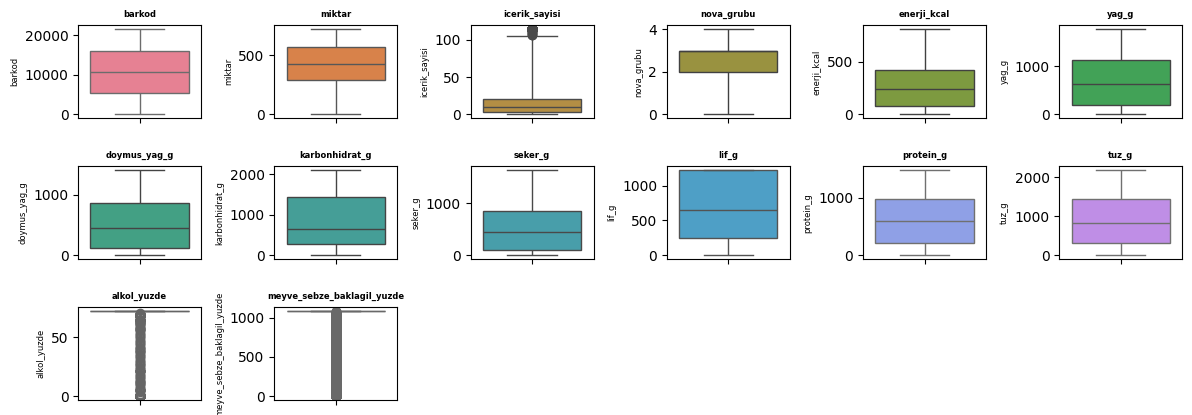

In [30]:
from sklearn.calibration import LabelEncoder
import seaborn as sns

veri = data.copy()

selected_columns = veri.select_dtypes(include=['number']).columns.tolist()

label_encoder = LabelEncoder()

for column in selected_columns:
    veri[column] = label_encoder.fit_transform(veri[column])

# Plot sayısını belirleyip subplotları ayarlayalım
fig, axes = plt.subplots(nrows=int(np.ceil(len(selected_columns)/3)), ncols=6, figsize=(12, 1 * int(np.ceil(len(selected_columns)/2))))

# Renk paleti seçimi
palette = sns.color_palette("husl", len(selected_columns))

# Boxplotları çizelim
axes = axes.flatten()
for i, col in enumerate(selected_columns):
    sns.boxplot(y=col, data=veri, ax=axes[i], color=palette[i], whis=5)
    axes[i].set_title(f'{col}', fontsize=6, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=6)

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grafik düzenini iyileştirelim
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=2.0)
plt.show()

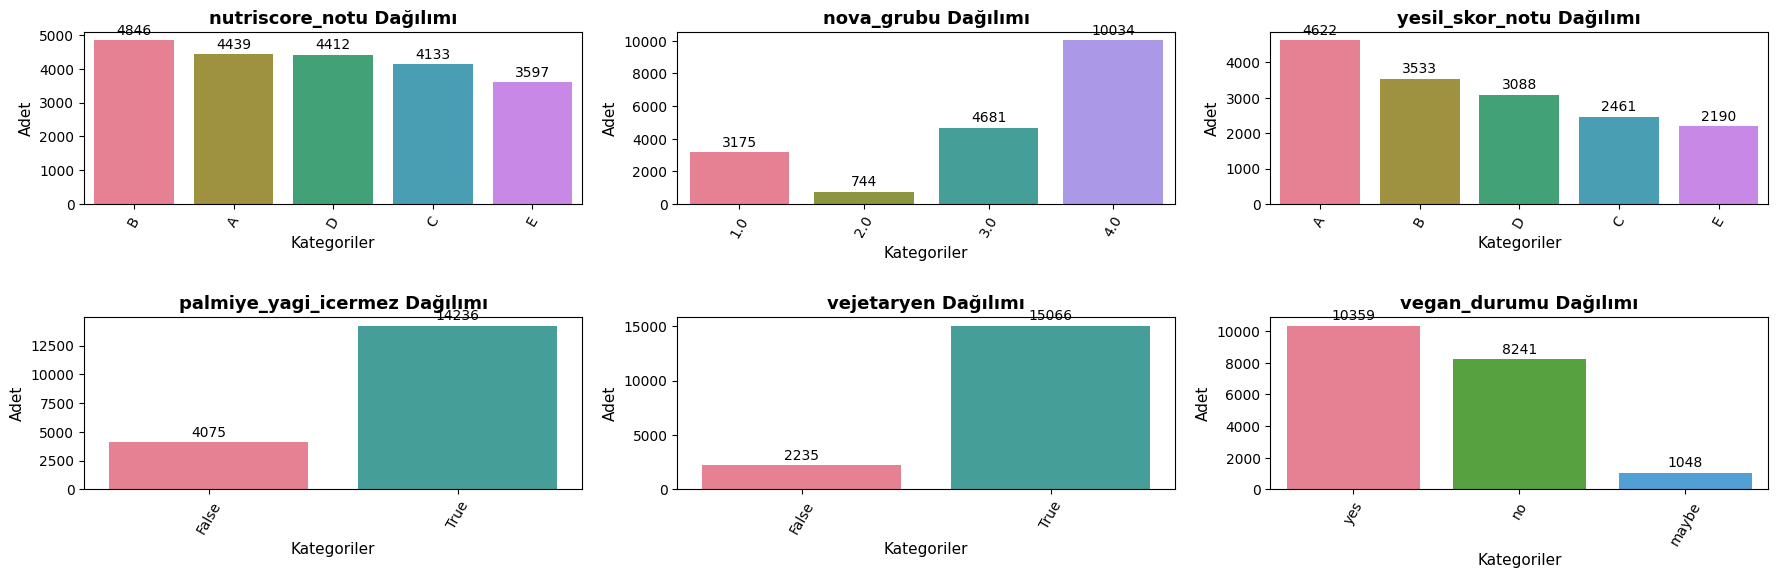

In [31]:
unique_counts = data.nunique()

categorical_columns = unique_counts[unique_counts <= 20].index.tolist()

n_cols = 3
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*3))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    val_counts = data[column].value_counts()
    sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='husl')
    axes[i].set_title(f'{column} Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Kategoriler", fontsize=11)
    axes[i].set_ylabel("Adet", fontsize=11)
    axes[i].tick_params(axis='x', rotation=60)

    # Her sütunun üzerine değerleri ekleyelim
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                         textcoords='offset points')

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=2.5)
plt.show()